In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

setting random seed to make our output reproducible

In [51]:
import random,numpy as np,torch
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

importing torch and setting device agnostics code

In [52]:
import torch
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

looking at kaggle input 

In [53]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


looking at added dataset into datasets folder

In [54]:
print(os.listdir("/kaggle/input/datasets/kmader"))

['skin-cancer-mnist-ham10000']


storing dataset path and looking at all the files available inside it 

In [55]:
dataset_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

print(os.listdir(dataset_path))

['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


1) HAM10000 stands for Human Against Machine with 10,000 training images.

It is a dataset of 10,015 dermatoscopic images of skin lesions used for multi-class skin-lesion classification.

The goal is:

Given an image of a skin lesion, predict what type of lesion it belongs to.

2) $$
\begin{array}{|c|l|l|}
\hline
\textbf{Code} & \textbf{Condition} & \textbf{Meaning} \\
\hline
\texttt{nv} & \text{Melanocytic nevi} & \text{Common moles} \\
\hline
\texttt{mel} & \text{Melanoma} & \text{Malignant skin cancer} \\
\hline
\texttt{bkl} & \text{Benign keratosis-like lesions} & \text{Benign lesions} \\
\hline
\texttt{bcc} & \text{Basal cell carcinoma} & \text{Common skin cancer} \\
\hline
\texttt{akiec} & \text{Actinic keratoses / intraepithelial carcinoma} & \text{Potentially precancerous/malignant} \\
\hline
\texttt{vasc} & \text{Vascular lesions} & \text{Blood-vessel-related lesions} \\
\hline
\texttt{df} & \text{Dermatofibroma} & \text{Benign skin lesion} \\
\hline
\end{array}
$$

3) HAM10000_metadata.csv: The CSV contains information about each image.
4) dx is our target label. This is what our neural network will learn.
5) The biggest issue: class imbalance

This is probably the most important thing to understand about HAM10000.

The 10,015 images aren't distributed equally among the 7 classes.

There are far more nv images than some of the rare classes.
6) we will not evaluate this project using accuracy alone.

We'll look at things like:

Precision
Recall
F1-score
Confusion matrix

converting csv files into dataframe

In [56]:
import pandas as pd

df = pd.read_csv(
    f"{dataset_path}/HAM10000_metadata.csv"
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


looking for length of dataset

In [57]:
len(df)

10015

looking for no of rows and columns inside dataframe

In [58]:
df.shape

(10015, 7)

looking for unique values inside 'dx' folder

In [59]:
df['dx'].unique()

array(['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'], dtype=object)

looking for no of items for each class in 'dx' 

In [60]:
df['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

converting no of items into percentage for each class in 'dx'

In [61]:
# percentage of each class in dx
dx_cls_per={}# it stores class:percentage for every class in dx

for cls in df['dx'].unique():
    dx_cls_per[cls] = (df['dx'] == cls).mean() * 100
dx_cls_per = dict(
    sorted(dx_cls_per.items(), key=lambda x: x[1], reverse=True)
)

dx_cls_per

{'nv': np.float64(66.94957563654518),
 'mel': np.float64(11.11333000499251),
 'bkl': np.float64(10.973539690464303),
 'bcc': np.float64(5.132301547678482),
 'akiec': np.float64(3.2651023464802793),
 'vasc': np.float64(1.417873190214678),
 'df': np.float64(1.1482775836245633)}

looking at data columns

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


looking at null values

In [63]:
# checking for null values
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Age has 57 null values.Checking for unique values inside age column

In [64]:
df['age'].unique()

array([80., 75., 60., 70., 55., 85., 65., 40., 50., 45., 35.,  0., 30.,
       nan,  5., 25., 20., 10., 15.])

In [65]:
# checking for percentage of missing values in column 'age'
100 * df['age'].isna().sum() / len(df)

np.float64(0.5691462805791313)

less than 1% of rows misses the value for age

Age has 57 null values. We will leave it intact since we are not using it in our model bcoz our model is an image classifier

In [66]:
# since we have images into two different folder we will combine them into one 
import os

image_dir1 = os.path.join(dataset_path, "HAM10000_images_part_1")
image_dir2 = os.path.join(dataset_path, "HAM10000_images_part_2")

image_paths = {}

for file in os.listdir(image_dir1):
    image_paths[os.path.splitext(file)[0]] = os.path.join(image_dir1, file)

for file in os.listdir(image_dir2):
    image_paths[os.path.splitext(file)[0]] = os.path.join(image_dir2, file)
len(image_paths)

10015

The general image path

image_id

   ↓
   
ISIC_0028933

   ↓
   
image_paths[image_id]

   ↓
   
/kaggle/input/.../ISIC_0028933.jpg

In [67]:
# looking at single image path
image_paths['ISIC_0028933']

'/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg'

In [68]:
# adding image paths into dataframe
df["image_path"] = df["image_id"].map(image_paths)# it maps image id with given image path
df[["image_id", "dx", "image_path"]].head()

,image_id,dx,image_path
0,ISIC_0027419,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [69]:
# checking for null values
df["image_path"].isna().sum()

np.int64(0)

found no null value

(600, 450)
bkl


(np.float64(-0.5), np.float64(599.5), np.float64(449.5), np.float64(-0.5))

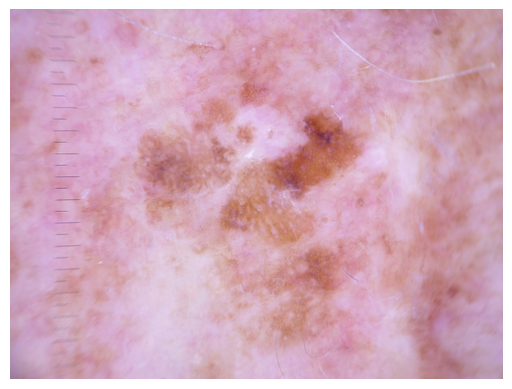

In [70]:
# looking at a single image
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(df.iloc[0]["image_path"])

print(img.size)
print(df.iloc[0]["dx"])

plt.imshow(img)
plt.axis("off")

splitting dataset into train, test and validation set

In [71]:
from sklearn.model_selection import train_test_split
set_seed()
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["dx"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

It first converts df into train and temp df then temp df is converted into test and val df therefore we have 70% train data,15% test data and 15% validation data.Here we have used stratify to keep the ratio of classes constant in every dataframe

Loading pretrained model--EfficientNetB2 

In [72]:
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

weights0 = EfficientNet_B2_Weights.DEFAULT

model0 = efficientnet_b2(weights=weights0)

Loading pretrained model's transform

In [73]:
# loading pretrained model0's transform
transform0 = weights0.transforms()
transform0

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

creating a dataset class to convert our images into a dataset

In [74]:
from torch.utils.data import Dataset
from PIL import Image
# creating a Dataset class since ImageFolder can't be used with the given structure of our images
class HAM10000Dataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        # it returns length of datset
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")
        label = row["label"]

        if self.transform:
            image = self.transform(image)
        # it return transformed image converted into RGB format and label for a given index
        return image, label

In [75]:
# creating transforms
from torchvision import transforms
# We use data augmentation in the training transform mainly to reduce overfitting
# and improve the model's ability to generalize to unseen skin-lesion images.
train_transform0 = transforms.Compose([
    # resizing according to model requirement
    transforms.Resize((288, 288)),
    # data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    # converting into tensors
    transforms.ToTensor(),
    # normalizing image tensors
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# No need to use data augmentation on val and test transform since model is not learning from these dataset they are just used for evaluation
test_transform0=transform0
val_transform0=transform0

In [76]:
class_names = sorted(df["dx"].unique())
class_names

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

In [77]:
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
class_to_idx

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

adding class_to_idx in dataframe and mapping them according to 'dx'

In [78]:
train_df["label"] = train_df["dx"].map(class_to_idx)
val_df["label"] = val_df["dx"].map(class_to_idx)
test_df["label"] = test_df["dx"].map(class_to_idx)

In [79]:
from torch.utils.data import DataLoader
set_seed()
# creating datasets
train_dataset0 = HAM10000Dataset(train_df, train_transform0)
val_dataset0 = HAM10000Dataset(val_df, test_transform0)
test_dataset0 = HAM10000Dataset(test_df, test_transform0)
# creating dataloader
train_dataloader0 = DataLoader(
    train_dataset0,
    batch_size=32,# small batch size saves space and computation is faster
    shuffle=True # to prevent model from memorizing
)

val_dataloader0 = DataLoader(
    val_dataset0,
    batch_size=32,
    shuffle=False # since we are only using it for evaluation no need to turn on shuffle
)

test_dataloader0 = DataLoader(
    test_dataset0,
    batch_size=32,
    shuffle=False # since we are only using it for evaluation no need to turn on shuffle
)

In [80]:
train_dataloader0,test_dataloader0,val_dataloader0

(<torch.utils.data.dataloader.DataLoader at 0x780c64a65250>,
 <torch.utils.data.dataloader.DataLoader at 0x780c52a539b0>)

In [81]:
len(train_dataloader0),len(test_dataloader0),len(val_dataloader0)

(220, 47, 47)

 we are using effnet b2 model.Looking at architecture of effnet b2

In [82]:
# let's see how's our model architecture
from torchinfo import summary

summary(
    model0,
    input_size=(1, 3, 288, 288)# To see model architecture we should give input size since this function does a forward pass on the given model
)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 1000]                 --
├─Sequential: 1-1                                       [1, 1408, 9, 9]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 144, 144]         --
│    │    └─Conv2d: 3-1                                 [1, 32, 144, 144]         864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 144, 144]         64
│    │    └─SiLU: 3-3                                   [1, 32, 144, 144]         --
│    └─Sequential: 2-2                                  [1, 16, 144, 144]         --
│    │    └─MBConv: 3-4                                 [1, 16, 144, 144]         1,448
│    │    └─MBConv: 3-5                                 [1, 16, 144, 144]         612
│    └─Sequential: 2-3                                  [1, 24, 72, 72]           --
│    │    └─MBConv: 3-6                                

In [83]:
# looking at a batch of image and label
img,label=next(iter(train_dataloader0))
# looking at shape of single image and label
img[0].shape,label[0]

(torch.Size([3, 288, 288]), tensor(2))

In [84]:
# generating a list of random images
import random
k=5
random_idx = random.sample(range(len(train_dataset0)), k)
img=[]
label=[]
for idx in random_idx:
    img.append(train_dataset0[idx][0])
    label.append(train_dataset0[idx][1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.193377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8382572].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1461596].


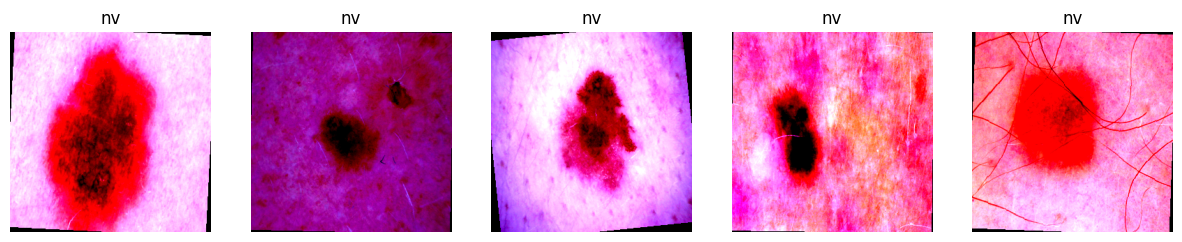

In [85]:
# plotting images
plt.figure(figsize=(15, 3))

for i in range(k):
    plt.subplot(1, k, i + 1)
    plt.imshow(img[i].permute(1, 2, 0))# Matplotlib expects img to be (Height,Width,Color Channel) but tensors produces img into (Color channel,Height,Width)
    plt.title(class_names[label[i]])
    plt.axis("off")

plt.show()

In [86]:
import torch.nn as nn
set_seed()
# changing model classifier layer according to no of classes present in our dataset
model0.classifier = nn.Sequential(nn.Dropout(p=0.3,inplace=True),
                                    nn.Linear(in_features=1408,
                                    out_features=len(class_names)
                                             )
                                )
                                    

In [87]:
model0.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=7, bias=True)
)

In [88]:
# shifting model to current device 
model0.to(device)
# this functions produces a single batch of img and label which is of size 32 for this case since our batch_size=32
img, label = next(iter(train_dataloader0))
# shifting input to current device to prevent device mismatch error
img=img.to(device)
output = model0(img)

print(img.shape)
print(output.shape)

torch.Size([32, 3, 288, 288])
torch.Size([32, 7])


 since our datset is highly imbalanced we create class_weight to give weightage to every class accordingly instead of equally

In [89]:
# it produces count of every class in sorted order
class_counts = train_df["label"].value_counts().sort_index()
# it gives weight to every class based on their counts, so that under-represented classes get higher weight and over-represented classes get lower weight — balancing their overall contribution to the loss
class_weights = len(train_df) / (len(class_names) * class_counts)
# converting class_weights to tensor for further uses
class_weights = torch.tensor(
    class_weights.values,
    dtype=torch.float32
)

class_weights

tensor([ 4.3731,  2.7817,  1.3022, 12.3633,  1.2855,  0.2134, 10.1154])

creating loss_fn considering class wise weightage

In [90]:
loss_fn0 = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

creating optimizer with weight decay to keep optimization process smooth.Weight decay adds a penalty that encourages the model's weights to remain small, which helps reduce overfitting and acts as a form of regularization

In [91]:
optimizer0 = torch.optim.AdamW(
    model0.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

doing a forward pass to check if the overall pipeline is working correctly or not

In [92]:
model0.eval()

with torch.inference_mode():
    img, label = next(iter(val_dataloader0))

    img = img.to(device)

    output = model0(img)

print(output.shape)

torch.Size([32, 7])


downloading going_modular from github to import functions

In [93]:
# downloading going_modular folder from github for using already coded python script such as engine.py and predict.py 
!git clone https://github.com/saransh1806/going_modular.git

fatal: destination path 'going_modular' already exists and is not an empty directory.


In [94]:
!ls

going_modular


In [95]:
# these are the scripts available inside going_modular
!ls going_modular

data_setup.py  engine.py       metrics.py  __pycache__
directory.py   loss_curves.py  predict.py  requirements.txt


In [96]:
from going_modular import engine

In [97]:
set_seed()
# this is a utility function inside engine.py which does a complete training and testing pipeline and stores model result
result_model0=engine.train(model=model0,
                     train_dataloader=train_dataloader0,
                     test_dataloader=val_dataloader0,
                     optimizer=optimizer0,
                     loss_fn=loss_fn0,
                     epochs=10,
                     device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.3000 | train_acc: 0.5581 | test_loss: 0.7812 | test_acc: 0.6726
Epoch: 2 | train_loss: 0.7242 | train_acc: 0.7270 | test_loss: 0.7162 | test_acc: 0.7125
Epoch: 3 | train_loss: 0.5228 | train_acc: 0.7753 | test_loss: 0.6947 | test_acc: 0.7744
Epoch: 4 | train_loss: 0.4271 | train_acc: 0.7953 | test_loss: 0.5315 | test_acc: 0.7504
Epoch: 5 | train_loss: 0.3667 | train_acc: 0.8190 | test_loss: 0.6419 | test_acc: 0.8163
Epoch: 6 | train_loss: 0.2876 | train_acc: 0.8433 | test_loss: 0.4788 | test_acc: 0.8103
Epoch: 7 | train_loss: 0.2524 | train_acc: 0.8597 | test_loss: 0.5501 | test_acc: 0.8302
Epoch: 8 | train_loss: 0.2475 | train_acc: 0.8636 | test_loss: 0.5544 | test_acc: 0.8409
Epoch: 9 | train_loss: 0.2224 | train_acc: 0.8750 | test_loss: 0.5736 | test_acc: 0.8257
Epoch: 10 | train_loss: 0.1995 | train_acc: 0.8893 | test_loss: 0.5916 | test_acc: 0.8110


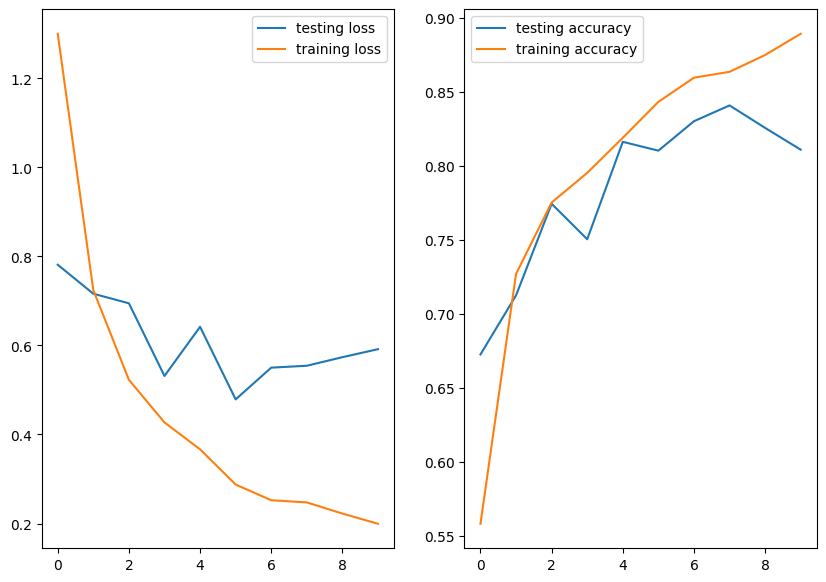

In [98]:
from going_modular import loss_curves
# this is a utility function inside loss_curves.py which generates graph based on model result
loss_curves.plot_loss_curves(result_model0)

we are getting some good looking curves.Loss is going down and accuracy is increasing

In [99]:
# Doing a forward pass with trained model on unseen data to check it's performance
val_loss0,val_acc0=engine.test_step(model0,
                                 val_dataloader0,
                                 loss_fn0,
                                 device)
val_loss0,val_acc0

(0.5916323022956543, 0.8109929078014184)

since accuracy alone is not sufficient we will plot confusion metric and look for precision,recall values and also print classification report to know more about the model for validation data(unseen data)


Classification Report - EfficientNet-B2
              precision    recall  f1-score   support

       akiec       0.88      0.59      0.71        49
         bcc       0.90      0.82      0.86        77
         bkl       0.69      0.78      0.73       165
          df       0.58      0.82      0.68        17
         mel       0.45      0.84      0.58       167
          nv       0.96      0.82      0.88      1006
        vasc       0.91      1.00      0.95        21

    accuracy                           0.81      1502
   macro avg       0.77      0.81      0.77      1502
weighted avg       0.87      0.81      0.83      1502



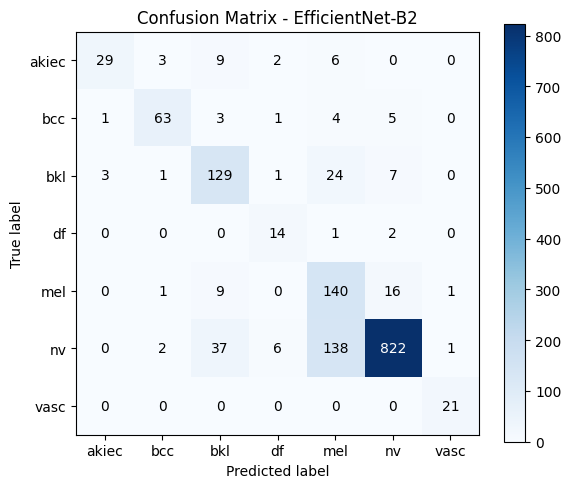

In [100]:
from going_modular import metrics
# this is a utility function inside metrics.py which generates classification report and confusion matrix
y_true,y_pred=metrics.evaluate_model(model0, val_dataloader0, class_names, device, model_name="EfficientNet-B2")

predicting on random image

In [101]:
import os
# checking if the random image is uploaded or not correctly
print(os.listdir("/kaggle/input/datasets/saransh1806/random-image-for-prediction"))

['Screenshot 2026-08-16 112301.png']


In [102]:
# since image is correctly uploaded,let's get the image path 
image_path = "/kaggle/input/datasets/saransh1806/random-image-for-prediction/Screenshot 2026-08-16 112301.png"

In [103]:
from PIL import Image
# opening image through loaded image path
image = Image.open(image_path).convert("RGB")


In [104]:
# it converts loaded image into image tensor using val_transform(since train_transform does a lot of data augmentation which changes the original image a lot therefore we use val_transform)
image_tensor = val_transform0(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


tensor([[2.8378e-04, 1.6117e-03, 7.0143e-04, 5.2903e-03, 9.3320e-03, 9.8036e-01,
         2.4161e-03]], device='cuda:0')

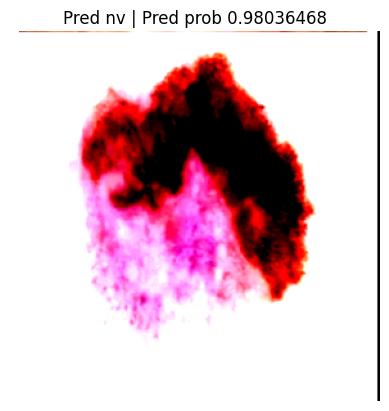

In [105]:
from going_modular import predict
# this is a utility function inside predict.py. It takes the random_image tensor and predict and plot on it using the trained model
predict.pred_and_plot(model0,
                  image_tensor,
                  class_names,
                  device)

saving  model weights.

In [106]:
# saving model weight which will be useful for loading and deploying model later.
torch.save(
    model0.state_dict(),
    "/kaggle/working/efficientnet_b2_ham10000.pth"
)
print("saved model weights")

saved model weights


loading pretrained model 2:Dense Net 121
This dataset has actually been trained on Dense Net 121 with baseline accuracy ranges from (80-94)% depending upon hyperparameter settings .We will build our model 2 on this architecture and see how it performs

In [107]:
from torchvision.models import densenet121, DenseNet121_Weights

weights1 = DenseNet121_Weights.DEFAULT
model1 = densenet121(weights=weights1)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]


In [108]:
# getting DenseNet-121 transform
transform1=weights1.transforms()
transform1

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [109]:
# creating train,test and validation trasnsforms to feed into dataset class
train_transform1 = transforms.Compose([
    # resizing according to model requirement
    transforms.Resize((224, 224)),
    # data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    # converting into tensors
    transforms.ToTensor(),
    # normalizing image tensors
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transform1=transform1
val_transform1=transform1

In [110]:
set_seed()
# creating train,test and validation dataset
train_dataset1 = HAM10000Dataset(train_df, train_transform1)
val_dataset1 = HAM10000Dataset(val_df, test_transform1)
test_dataset1 = HAM10000Dataset(test_df, test_transform1)
# creating train,test and validation dataloader
train_dataloader1 = DataLoader(
    train_dataset1,
    batch_size=32,# small batch size saves space and computation is faster
    shuffle=True # to prevent model from memorizing
)

val_dataloader1 = DataLoader(
    val_dataset1,
    batch_size=32,
    shuffle=False # since we are only using it for evaluation no need to turn on shuffle
)

test_dataloader1 = DataLoader(
    test_dataset1,
    batch_size=32,
    shuffle=False # since we are only using it for evaluation no need to turn on shuffle
)

In [111]:
# let's see how's our model architecture
from torchinfo import summary

summary(
    model1,
    input_size=(1, 3, 288, 288)# since this function does a forward pass to get model architecture therefore we need to pass model's input shape
)

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [1, 1000]                 --
├─Sequential: 1-1                        [1, 1024, 9, 9]           --
│    └─Conv2d: 2-1                       [1, 64, 144, 144]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 144, 144]         128
│    └─ReLU: 2-3                         [1, 64, 144, 144]         --
│    └─MaxPool2d: 2-4                    [1, 64, 72, 72]           --
│    └─_DenseBlock: 2-5                  [1, 256, 72, 72]          --
│    │    └─_DenseLayer: 3-1             [1, 32, 72, 72]           45,440
│    │    └─_DenseLayer: 3-2             [1, 32, 72, 72]           49,600
│    │    └─_DenseLayer: 3-3             [1, 32, 72, 72]           53,760
│    │    └─_DenseLayer: 3-4             [1, 32, 72, 72]           57,920
│    │    └─_DenseLayer: 3-5             [1, 32, 72, 72]           62,080
│    │    └─_DenseLayer: 3-6             [1, 32, 72, 72]     

In [112]:
# looking at a batch of image and label
img,label=next(iter(train_dataloader1))
# looking at shape of single image and label
img[0].shape,label[0]

(torch.Size([3, 224, 224]), tensor(2))

In [113]:
# generating a list of random images
import random
k=5
random_idx = random.sample(range(len(train_dataset1)), k)
img=[]
label=[]
for idx in random_idx:
    img.append(train_dataset1[idx][0])
    label.append(train_dataset1[idx][1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0947855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.0713727].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8208281].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0776608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.129035].


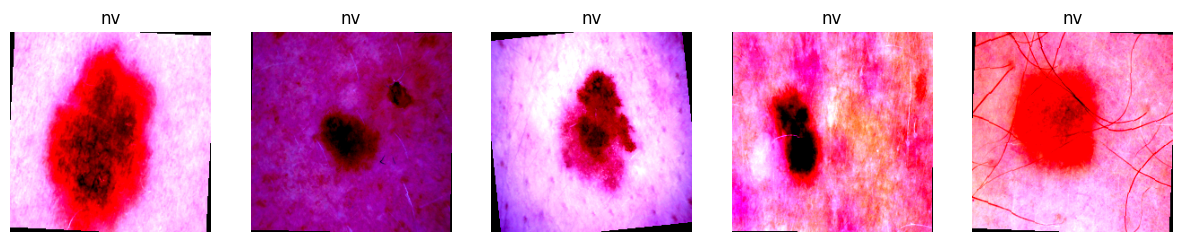

In [114]:
# plotting images
plt.figure(figsize=(15, 3))

for i in range(k):
    plt.subplot(1, k, i + 1)
    plt.imshow(img[i].permute(1, 2, 0))# matplotlib expects image in shape (Height,Width,Color channel) but tensor produces images in shape (Color channel, Height,Width) hence we use permute to move color_channel dim from 0 to 2.
    plt.title(class_names[label[i]])
    plt.axis("off")

plt.show()

In [115]:
# original classifier
model1.classifier

Linear(in_features=1024, out_features=1000, bias=True)

In [116]:
import torch.nn as nn
set_seed()
# changing model classifier layer according to no of classes present in our dataset
model1.classifier = nn.Sequential(nn.Dropout(p=0.3,inplace=True),
                                    nn.Linear(model1.classifier.in_features,
                                    out_features=len(class_names)
                                             )
                                )
                                    

In [117]:
# current model classifier
model1.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1024, out_features=7, bias=True)
)

In [118]:
# checking if the pipeline is working correcty or not through a forward pass
model1.to(device)
img, label = next(iter(train_dataloader1))# this function gives one batch of image and label
img=img.to(device) # shifting input to current device
output = model1(img)# forward pass

print(img.shape)
print(output.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 7])


In [119]:
loss_fn1 = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

In [120]:
optimizer1 = torch.optim.AdamW(
    model1.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [121]:
# checking if the evaluation mode is working correctly or not and what output shape it produces
model1.eval()

with torch.inference_mode():
    img, label = next(iter(val_dataloader1)) # this function gives one batch of image and label

    img = img.to(device)# shifting input to current device

    output = model1(img) # forward pass

print(output.shape)

torch.Size([32, 7])


In [122]:
set_seed()
result_model1=engine.train(model=model1,
                     train_dataloader=train_dataloader1,
                     test_dataloader=val_dataloader1,
                     optimizer=optimizer1,
                     loss_fn=loss_fn1,
                     epochs=10,
                     device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.2009 | train_acc: 0.5780 | test_loss: 0.8205 | test_acc: 0.6666
Epoch: 2 | train_loss: 0.7883 | train_acc: 0.6959 | test_loss: 0.6896 | test_acc: 0.7026
Epoch: 3 | train_loss: 0.6595 | train_acc: 0.7337 | test_loss: 0.6555 | test_acc: 0.7730
Epoch: 4 | train_loss: 0.5565 | train_acc: 0.7570 | test_loss: 0.6491 | test_acc: 0.7418
Epoch: 5 | train_loss: 0.5337 | train_acc: 0.7668 | test_loss: 0.6312 | test_acc: 0.7350
Epoch: 6 | train_loss: 0.4611 | train_acc: 0.7879 | test_loss: 0.5433 | test_acc: 0.7798
Epoch: 7 | train_loss: 0.3968 | train_acc: 0.8026 | test_loss: 0.6246 | test_acc: 0.8235
Epoch: 8 | train_loss: 0.4102 | train_acc: 0.8053 | test_loss: 0.5965 | test_acc: 0.7943
Epoch: 9 | train_loss: 0.3440 | train_acc: 0.8241 | test_loss: 0.6950 | test_acc: 0.8176
Epoch: 10 | train_loss: 0.2879 | train_acc: 0.8403 | test_loss: 0.5969 | test_acc: 0.8303


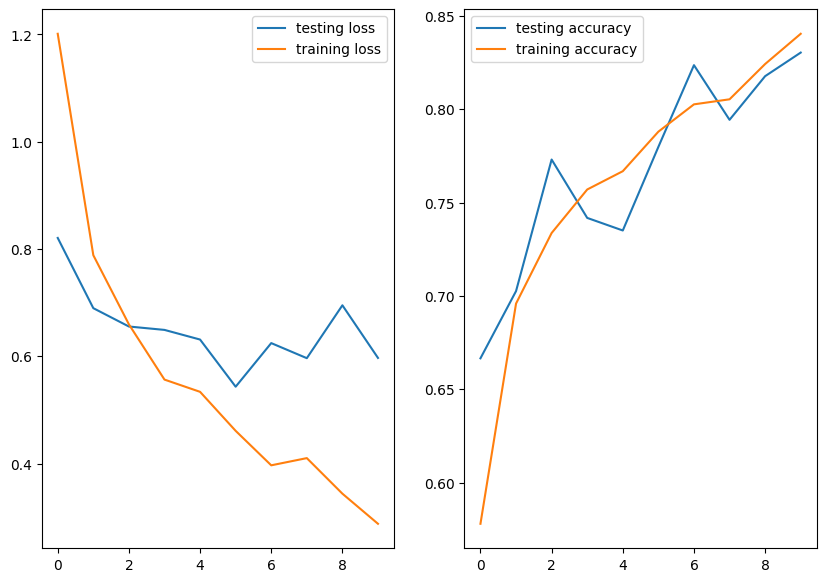

In [123]:
# printing loss curves from the model results
loss_curves.plot_loss_curves(result_model1)

In [124]:
# looking at trained model performance on unseen data(val data) and printinig its loss and accuracy
val_loss1,val_acc1=engine.test_step(model1,
                                 val_dataloader1,
                                 loss_fn1,
                                 device)
val_loss1,val_acc1

(0.5969466392664199, 0.8302748226950355)


Classification Report - DenseNet-121
              precision    recall  f1-score   support

       akiec       0.68      0.88      0.77        49
         bcc       0.81      0.82      0.81        77
         bkl       0.63      0.81      0.71       165
          df       0.67      0.71      0.69        17
         mel       0.59      0.67      0.63       167
          nv       0.94      0.86      0.90      1006
        vasc       0.95      0.86      0.90        21

    accuracy                           0.83      1502
   macro avg       0.75      0.80      0.77      1502
weighted avg       0.85      0.83      0.84      1502



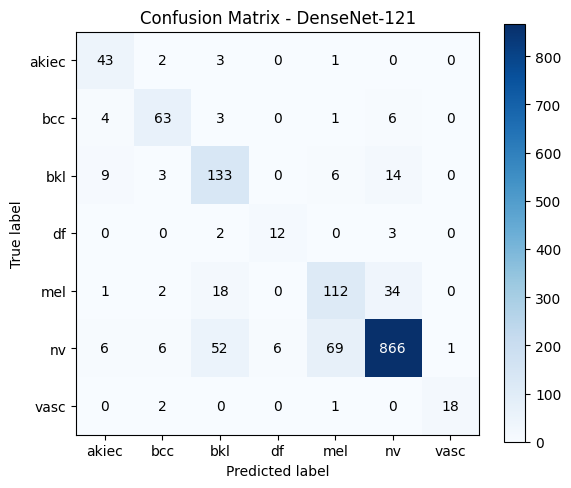

In [125]:
# evaluating model based on different metrics like classification report
y_true,y_pred=metrics.evaluate_model(model1, val_dataloader1, class_names, device, model_name="DenseNet-121")

In [126]:
# opening random image through image path(image is downloaded from google and added as input on kaggle and then loaded through the given image path)
from PIL import Image

image = Image.open(image_path).convert("RGB")


In [127]:
# converting image into tensor using val_transform(val transform is used to predict output without changing much in image since train_transform applys a lot of data augmentation)
image_tensor = val_transform1(image)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7906162..2.5528543].


tensor([[4.4160e-04, 6.9071e-04, 8.7195e-03, 6.0789e-04, 9.7635e-01, 1.3093e-02,
         9.6310e-05]], device='cuda:0')

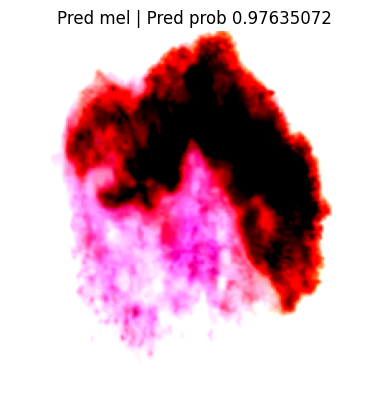

In [128]:
# predicting and plotting model's output on random image
predict.pred_and_plot(model1,
                  image_tensor,
                  class_names,
                  device)

In [129]:
# saving model's weight
torch.save(
    model1.state_dict(),
    "/kaggle/working/DenseNet_121_ham10000.pth"
)
print("saved model weights")

saved model weights


In [130]:
# Comparing between Model0 and Model1.
# We will look for precision and recall scores for every class.Accuracy of both the model.
# Model weight.Since we are going to deploy the best model we must keep in mind the size
# of model.

In [131]:
model0_size=sum(p.numel() for p in model0.parameters())* 4 / (1024 ** 2)# 4 is multiplied since parameters are stored in float32 which takes 4 byte(32 bit)
model1_size=sum(p.numel() for p in model1.parameters())* 4 / (1024 ** 2)
print(f"the size of model0 is {model0_size:.2f} MB")
print(f"the size of model1 is {model1_size:.2f} MB")

the size of model0 is 29.41 MB
the size of model1 is 26.55 MB


Both model have got almost equal weight hence size is not an issue in deployment

Downloading model weights for both model by zipping them into one 

In [132]:
!zip -j models.zip /kaggle/working/efficientnet_b2_ham10000.pth /kaggle/working/DenseNet_121_ham10000.pth

  adding: efficientnet_b2_ham10000.pth (deflated 8%)
  adding: DenseNet_121_ham10000.pth (deflated 7%)


In [133]:
from IPython.display import FileLink
FileLink(r'models.zip')

/kaggle/working/models.zip

## Model Comparison & Conclusion

We trained two pretrained backbones — EfficientNet-B2 and DenseNet-121 — on the same
train/val/test split, using the same class-weighted loss and optimizer settings, so the
comparison below is apples-to-apples. All numbers below are taken directly from the
validation-set evaluation cells above (val accuracy/loss and the per-class classification
reports).

| Metric                    | EfficientNet-B2 | DenseNet-121 |
|----------------------------|-----------------|---------------|
| Validation Accuracy        | 0.811           | 0.830         |
| Validation Loss            | 0.592           | 0.597         |
| Melanoma (mel) Precision   | 0.45            | 0.59          |
| Melanoma (mel) Recall      | 0.84            | 0.67          |
| Overall Macro F1           | 0.77            | 0.77          |
| Trainable Parameters       | ~9.11M          | ~7.98M        |
| Saved Model Size           | 29.41 MB        | 26.55 MB      |

**Overall accuracy**: DenseNet-121 actually edges out EfficientNet-B2 on validation accuracy
(83.0% vs 81.1%), and the two models are essentially tied on macro F1 (0.77 for both), so
neither model is a clean winner on "how often is it right overall."

**Fine-tuning strategy**: Both models were fully fine-tuned — all backbone layers remained
trainable, not just the replaced classifier head — using a relatively low learning rate
(1e-4) to adapt pretrained ImageNet features to dermatoscopic images without catastrophic
forgetting. Given the significant domain gap between ImageNet and dermatoscopic imagery,
full fine-tuning was chosen over freezing the backbone, and the dataset size (10,015 images)
was large enough to support it safely.

**Melanoma detection trade-off**: This is the most clinically important class, and it's where
the two models actually diverge. EfficientNet-B2 catches far more true melanomas — recall
0.84 vs DenseNet's 0.67 — but pays for it with lower precision (0.45 vs 0.59), meaning more
than half of its melanoma predictions are false alarms. DenseNet-121 is the opposite: fewer
false alarms, but it misses roughly a third of actual melanomas that EfficientNet-B2 would
have flagged. In a screening context, recall is usually prioritized (missing a real melanoma
is worse than a false alarm that a dermatologist rules out on follow-up), so EfficientNet-B2's
recall edge is the meaningful differentiator here, not its accuracy.

**Efficiency**: DenseNet-121 is smaller (~7.98M vs ~9.11M trainable parameters, 26.55 MB vs
29.41 MB) and also has the higher validation accuracy — so on pure efficiency-vs-accuracy
grounds DenseNet-121 is the stronger model. It's EfficientNet-B2's melanoma recall, not its
accuracy or size, that justifies its selection below.

**Bug found and fixed along the way**: An early DenseNet-121 run used a train-time resize of
288x288, inherited by copy-paste from the EfficientNet-B2 pipeline, while DenseNet's pretrained
weights actually expect 224x224 input. This train/eval resolution mismatch produced a visibly
unstable test-loss curve. After correcting the resize to 224x224 and retraining from a fresh
pretrained checkpoint, training stabilized and the results above reflect the corrected run.

**Chosen model for deployment**: We select **EfficientNet-B2** as the primary deployed model.
It does *not* have the higher overall accuracy or a smaller footprint — DenseNet-121 wins on
both of those. The reason to choose it is the melanoma recall gap (0.84 vs 0.67): in a
screening tool, catching more true melanomas is worth the added false positives, since a
missed malignant case is far costlier than an unnecessary dermatologist follow-up. DenseNet-121
is kept available in the demo as a secondary opinion, given its higher accuracy, better
melanoma precision, and smaller footprint — flagging cases where the two models disagree is a
reasonable lightweight safeguard for a screening tool.

**Limitations**: Both models are trained and evaluated on HAM10000 only, have not been tested
on an external dataset, and have not been clinically validated. Melanoma precision/recall for
both models falls short of what would be required for real diagnostic use. This project is for
educational and portfolio purposes only and must not be used for actual medical diagnosis.

Now evaluating the chosen model (EfficientNet-B2) on the held-out test set — this data was
never used during training or model selection, so this is the honest generalization estimate.

In [134]:
set_seed()
test_loss0, test_acc0 = engine.test_step(model0, test_dataloader0, loss_fn0, device)
test_loss0, test_acc0

(0.6643876975521128, 0.81305765271105)

In [135]:
set_seed()
test_loss1, test_acc1 = engine.test_step(model1, test_dataloader1, loss_fn1, device)
test_loss1, test_acc1

(0.8734256866130423, 0.8030413520933425)

Definitely EfficientNet-B2 is performing well on unseen test data compared with DenseNet-121 since the loss for DenseNet is way higher than EfficientNet-B2